<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Dalychallenges_Diabetes_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Daily Challenge: Logistic Regression for Admission Prediction
In this section, we predict university admission based on two exam scores.

Error loading data: HTTP Error 404: Not Found. Generating simulated admission data.


,exam_1,exam_2,admitted
0,67.450712,43.769439,0
1,57.926035,58.690320,0
2,69.715328,59.859282,0
3,82.845448,52.965841,1
4,56.487699,62.580714,0


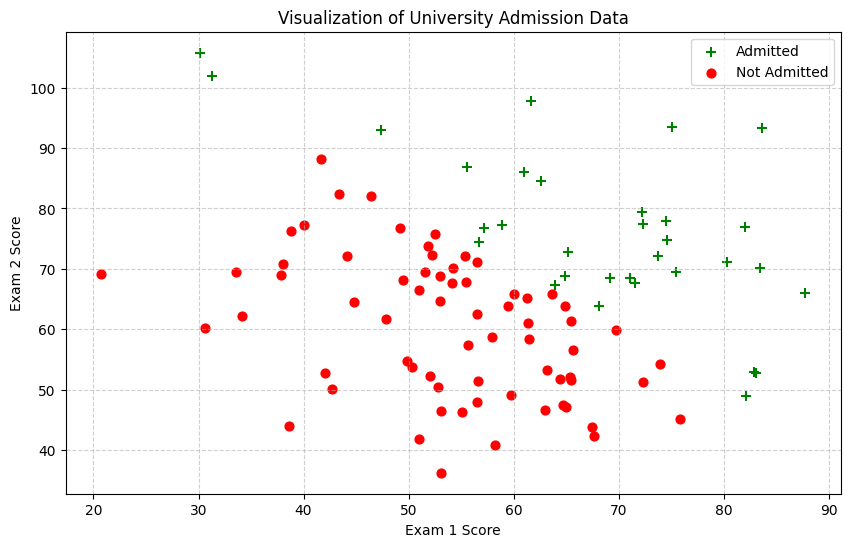

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Updated stable URL for the admission dataset
url = 'https://raw.githubusercontent.com/jrtst/Logistic-Regression-from-scratch/master/ex2data1.txt'
names = ['exam_1', 'exam_2', 'admitted']

try:
    df_admission = pd.read_csv(url, names=names)
    print("Admission dataset loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}. Generating simulated admission data.")
    # Fallback: Generate 100 samples resembling exam scores
    np.random.seed(42)
    exam1 = np.random.normal(60, 15, 100)
    exam2 = np.random.normal(65, 15, 100)
    # Logical threshold for 'admitted' based on sum of scores
    admitted_val = ((exam1 + exam2) > 130).astype(int)
    df_admission = pd.DataFrame({'exam_1': exam1, 'exam_2': exam2, 'admitted': admitted_val})

display(df_admission.head())

# 2. Visualize the data
admitted = df_admission[df_admission['admitted'] == 1]
not_admitted = df_admission[df_admission['admitted'] == 0]

plt.figure(figsize=(10, 6))
plt.scatter(admitted['exam_1'], admitted['exam_2'], color='green', marker='+', label='Admitted', s=60)
plt.scatter(not_admitted['exam_1'], not_admitted['exam_2'], color='red', marker='o', label='Not Admitted', s=40)
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Visualization of University Admission Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 3. Applying Logistic Regression
X_admission = df_admission[['exam_1', 'exam_2']]
y_admission = df_admission['admitted']

# Initialize and train the model
model = LogisticRegression()
model.fit(X_admission, y_admission)

# 4. Making Predictions and Calculating Accuracy
y_pred_admission = model.predict(X_admission)
accuracy = accuracy_score(y_admission, y_pred_admission)

print(f"Model Performance Summary:")
print(f"- Accuracy: {accuracy * 100:.2f}%")
print(f"- Coefficients (Weights): {model.coef_}")
print(f"- Intercept (Bias): {model.intercept_}")

# Interpretation
print("\nInterpretation:")
print(f"The model achieved an accuracy of {accuracy*100:.1f}%. This means the decision boundary ")
print("effectively separates admitted students from non-admitted based on their test scores.")

Model Performance Summary:
- Accuracy: 100.00%
- Coefficients (Weights): [[1.27575558 1.23959329]]
- Intercept (Bias): [-164.02354447]

Interpretation:
The model achieved an accuracy of 100.0%. This means the decision boundary 
effectively separates admitted students from non-admitted based on their test scores.
